# 案例一：HINGRL 课堂教学 Notebook

对应脚本：`drug repositioning/dda/HINGRL/run_demo.py`

本案例聚焦药物-疾病关联预测任务，课堂主线保持为一条清晰的教学链路：

1. 认识异构网络中的节点、边和特征
2. 理解样本构造与交叉验证的基本方法
3. 观察模型在 `B-Dataset` 上的训练结果与评估指标
4. 将 `F-Dataset` 留作课后迁移练习


## 教学目标

完成这份 Notebook 后，应该能回答下面三个问题：

1. HINGRL 为什么要同时使用节点属性特征和图嵌入特征？
2. 药物-疾病关联预测中的负样本是如何构造的？
3. 为什么这里既要看 `AUC`，也要看 `AUPR`？


In [1]:
from pathlib import Path
import math
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import auc, precision_recall_curve, roc_curve

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.unicode_minus"] = False


In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parents[2]
HINGRL_DIR = PROJECT_ROOT / "drug repositioning" / "dda" / "HINGRL"
DATA_DIR = HINGRL_DIR / "data"
OUTPUT_DIR = HINGRL_DIR / "demo_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
DATASET = "B-Dataset"
HOMEWORK_DATASET = "F-Dataset"
FOLD_NUM = 5
N_ESTIMATORS = 100

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("项目根目录:", PROJECT_ROOT)
print("当前课堂数据集:", DATASET)
print("课后作业数据集:", HOMEWORK_DATASET)
print("结果输出目录:", OUTPUT_DIR)
print(f"参数配置: fold_num={FOLD_NUM}, n_estimators={N_ESTIMATORS}, seed={RANDOM_SEED}")


项目根目录: C:\Users\Steve\Desktop\Research\Book\code\Chapter6\6_2
当前课堂数据集: B-Dataset
课后作业数据集: F-Dataset
结果输出目录: C:\Users\Steve\Desktop\Research\Book\code\Chapter6\6_2\drug repositioning\dda\HINGRL\demo_outputs
参数配置: fold_num=5, n_estimators=100, seed=42


## 1. 方法准备

下面保留了与 `run_demo.py` 对应的核心函数，用来支撑整节课的主流程：

1. 读取药物、疾病和特征数据
2. 生成负样本并构造配对样本
3. 组织 K 折交叉验证
4. 用随机森林完成预测与评估

教学时建议把重点放在“每个函数解决了什么问题”，而不是逐行解释代码细节。


In [3]:
def partition(ls, size):
    return [ls[i:i + size] for i in range(0, len(ls), size)]


def load_data(dataset_name):
    dset = DATA_DIR / dataset_name
    dr_di = pd.read_csv(dset / "DrDiNum.csv", header=None)
    dr_pr = pd.read_csv(dset / "DrPrNum.csv", header=None)
    di_pr = pd.read_csv(dset / "DiPrNum.csv", header=None)
    drug_names = pd.read_csv(dset / "drugName.csv", header=None, names=["id", "name"])
    disease_names = pd.read_csv(dset / "diseaseName.csv", header=None, names=["id", "name"])
    attribute = pd.read_csv(dset / "AllNodeAttribute.csv", header=None, index_col=0).iloc[:, 1:]
    embedding = pd.read_csv(dset / "AllEmbedding_DeepWalk.txt", sep=" ", header=None, skiprows=1)
    embedding = embedding.sort_values(0, ascending=True)
    embedding.set_index([0], inplace=True)
    return dr_di, dr_pr, di_pr, drug_names, disease_names, attribute, embedding


def generate_negative_samples(positive_pairs, all_drugs, all_diseases):
    positive_set = set(map(tuple, positive_pairs))
    negative_set = set()
    while len(negative_set) < len(positive_pairs):
        pair = (random.choice(all_drugs), random.choice(all_diseases))
        if pair not in positive_set and pair not in negative_set:
            negative_set.add(pair)
    return [list(pair) for pair in negative_set]


def build_feature_vector(pair_ids_col0, pair_ids_col1, attribute, embedding):
    feat_a = pd.concat([attribute.loc[pair_ids_col0], embedding.loc[pair_ids_col0]], axis=1).reset_index(drop=True)
    feat_b = pd.concat([attribute.loc[pair_ids_col1], embedding.loc[pair_ids_col1]], axis=1).reset_index(drop=True)
    return pd.concat([feat_a, feat_b], axis=1).values


def prepare_cv_folds(dr_di, negative_df, attribute, embedding, fold_num):
    n = len(dr_di)
    shuffled_idx = random.sample(range(n), n)
    fold_size = math.ceil(n / fold_num)
    fold_indices = partition(shuffled_idx, fold_size)
    max_len = max(len(fold) for fold in fold_indices)
    fold_matrix = np.full((fold_num, max_len), -1, dtype=int)

    for fi, fold in enumerate(fold_indices):
        fold_matrix[fi, :len(fold)] = fold

    neg_array = negative_df.values
    pos_array = dr_di.values
    folds = []

    for i in range(fold_num):
        test_idx = fold_matrix[i]
        test_idx = test_idx[test_idx >= 0]
        train_idx = np.concatenate([fold_matrix[j][fold_matrix[j] >= 0] for j in range(fold_num) if j != i])

        pos_train = pos_array[train_idx]
        pos_test = pos_array[test_idx]
        neg_train = neg_array[train_idx]
        neg_test = neg_array[test_idx]

        train_pairs = np.vstack([pos_train, neg_train])
        test_pairs = np.vstack([pos_test, neg_test])
        y_train = np.array([1] * len(pos_train) + [0] * len(neg_train))
        y_test = np.array([1] * len(pos_test) + [0] * len(neg_test))

        X_train = build_feature_vector(train_pairs[:, 0].tolist(), train_pairs[:, 1].tolist(), attribute, embedding)
        X_test = build_feature_vector(test_pairs[:, 0].tolist(), test_pairs[:, 1].tolist(), attribute, embedding)
        folds.append({"X_train": X_train, "X_test": X_test, "y_train": y_train, "y_test": y_test})

    return folds


def interpolate_pr(recall, precision, mean_recall):
    recall_inc = recall[::-1]
    precision_inc = precision[::-1]
    recall_unique, unique_idx = np.unique(recall_inc, return_index=True)
    precision_unique = precision_inc[unique_idx]
    return np.interp(mean_recall, recall_unique, precision_unique)


def evaluate_dataset(dataset_name, fold_num, n_estimators):
    dr_di, dr_pr, di_pr, drug_names, disease_names, attribute, embedding = load_data(dataset_name)
    negative_pairs = generate_negative_samples(
        dr_di.values.tolist(),
        drug_names["id"].tolist(),
        disease_names["id"].tolist(),
    )
    negative_df = pd.DataFrame(negative_pairs, columns=["drug_id", "disease_id"])
    folds = prepare_cv_folds(dr_di, negative_df, attribute, embedding, fold_num)

    mean_fpr = np.linspace(0, 1, 500)
    mean_recall = np.linspace(0, 1, 500)
    tprs, precisions = [], []
    aucs, auprs = [], []
    fold_rows = []

    for i, fold in enumerate(folds, start=1):
        clf = RandomForestClassifier(n_estimators=n_estimators, n_jobs=1, random_state=RANDOM_SEED)
        clf.fit(fold["X_train"], fold["y_train"])
        proba = clf.predict_proba(fold["X_test"])[:, 1]

        fpr, tpr, _ = roc_curve(fold["y_test"], proba)
        precision, recall, _ = precision_recall_curve(fold["y_test"], proba)

        fold_auc = auc(fpr, tpr)
        fold_aupr = auc(recall[::-1], precision[::-1])

        aucs.append(fold_auc)
        auprs.append(fold_aupr)

        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        precisions.append(interpolate_pr(recall, precision, mean_recall))

        fold_rows.append({"fold": i, "auc": round(float(fold_auc), 6), "aupr": round(float(fold_aupr), 6)})

    return {
        "dr_di": dr_di,
        "dr_pr": dr_pr,
        "di_pr": di_pr,
        "drug_names": drug_names,
        "disease_names": disease_names,
        "attribute": attribute,
        "embedding": embedding,
        "negative_df": negative_df,
        "folds": folds,
        "fold_metrics": pd.DataFrame(fold_rows),
        "mean_fpr": mean_fpr,
        "mean_tpr": np.mean(tprs, axis=0),
        "std_tpr": np.std(tprs, axis=0),
        "mean_recall": mean_recall,
        "mean_precision": np.mean(precisions, axis=0),
        "std_precision": np.std(precisions, axis=0),
        "mean_auc": float(np.mean(aucs)),
        "std_auc": float(np.std(aucs)),
        "mean_aupr": float(np.mean(auprs)),
        "std_aupr": float(np.std(auprs)),
    }


def plot_metrics(result, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
    color = "#1f77b4"

    axes[0].plot(result["mean_fpr"], result["mean_tpr"], color=color, lw=2.5,
                 label=f"B-Dataset (AUC={result['mean_auc']:.4f} ± {result['std_auc']:.4f})")
    axes[0].fill_between(
        result["mean_fpr"],
        np.maximum(result["mean_tpr"] - result["std_tpr"], 0),
        np.minimum(result["mean_tpr"] + result["std_tpr"], 1),
        color=color, alpha=0.15
    )
    axes[0].plot([0, 1], [0, 1], "--", color="gray", lw=1.2, label="Random baseline")
    axes[0].set_title("ROC Curve on B-Dataset")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].legend(loc="lower right", fontsize=8)

    axes[1].plot(result["mean_recall"], result["mean_precision"], color=color, lw=2.5,
                 label=f"B-Dataset (AUPR={result['mean_aupr']:.4f} ± {result['std_aupr']:.4f})")
    axes[1].fill_between(
        result["mean_recall"],
        np.maximum(result["mean_precision"] - result["std_precision"], 0),
        np.minimum(result["mean_precision"] + result["std_precision"], 1),
        color=color, alpha=0.15
    )
    axes[1].axhline(0.5, linestyle="--", color="gray", lw=1.2, label="Balanced baseline")
    axes[1].set_title("PR Curve on B-Dataset")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].legend(loc="lower left", fontsize=8)

    fig.suptitle("HINGRL Classroom Demo: B-Dataset", fontsize=14, y=1.02)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


## 2. 数据与任务认识

这一节先不急着讲模型，而是先把问题背景讲清楚：

- `B-Dataset` 中包含多少药物、多少疾病、多少已知关联
- 节点属性和 DeepWalk 嵌入分别扮演什么角色
- 课堂上的预测对象到底是什么

只有先理解数据规模和任务定义，后面的训练结果才更容易解释。


In [4]:
result = evaluate_dataset(DATASET, FOLD_NUM, N_ESTIMATORS)

summary_df = pd.DataFrame({
    "项目": ["药物-疾病正样本", "药物-蛋白关联", "疾病-蛋白关联", "药物节点", "疾病节点", "属性维度", "DeepWalk 维度"],
    "数值": [
        len(result["dr_di"]),
        len(result["dr_pr"]),
        len(result["di_pr"]),
        len(result["drug_names"]),
        len(result["disease_names"]),
        result["attribute"].shape[1],
        result["embedding"].shape[1],
    ],
})
summary_df


加载数据集: B-Dataset
药物-疾病正样本数   : 18416
药物-蛋白关联数     : 11107
疾病-蛋白关联数     : 25087
药物节点数          : 269
疾病节点数          : 598
属性特征维度        : 64
DeepWalk 嵌入维度   : 64
生成负样本，目标数量: 18416
负样本生成完成: 18416
第 1/5 折 | 训练样本: 29464 | 测试样本: 7368
第 2/5 折 | 训练样本: 29464 | 测试样本: 7368
第 3/5 折 | 训练样本: 29464 | 测试样本: 7368
第 4/5 折 | 训练样本: 29464 | 测试样本: 7368
第 5/5 折 | 训练样本: 29472 | 测试样本: 7360
开始模型评估: B-Dataset
第 1 折 | AUC = 0.8743 | AUPR = 0.8644
第 2 折 | AUC = 0.8714 | AUPR = 0.8613
第 3 折 | AUC = 0.8836 | AUPR = 0.8762
第 4 折 | AUC = 0.8761 | AUPR = 0.8711
第 5 折 | AUC = 0.8758 | AUPR = 0.8712
B-Dataset 汇总 | mean AUC = 0.8762 ± 0.0040 | mean AUPR = 0.8689 ± 0.0053


         项目    数值
   药物-疾病正样本 18416
    药物-蛋白关联 11107
    疾病-蛋白关联 25087
       药物节点   269
       疾病节点   598
       属性维度    64
DeepWalk 维度    64

## 3. 样本构造与特征表示

HINGRL 不是直接把原始边送进分类器，而是先把药物-疾病对整理成监督学习样本。

这一节建议重点强调：

1. 正负样本数量保持 1:1
2. 每个样本由两个节点的属性特征和图嵌入拼接而成
3. K 折划分的作用是让评估更稳定


In [5]:
print("负样本预览：")
display(result["negative_df"].head())

print("第一折训练集特征维度:", result["folds"][0]["X_train"].shape)
print("第一折测试集特征维度:", result["folds"][0]["X_test"].shape)


负样本预览：
 drug_id  disease_id
      77        1564
      70        1376
     254        1197
     125        1312
      42        1543

第一折训练集特征维度: (29464, 256)
第一折测试集特征维度: (7368, 256)


## 4. 模型训练与结果评估

这里使用随机森林作为分类器，原因是：

1. 对拼接后的混合特征较稳定
2. 训练过程清晰，适合课堂演示
3. 可以直接输出概率，便于计算 `ROC/AUC` 和 `PR/AUPR`

建议先看每一折结果，再看平均表现。


In [6]:
metrics_df = result["fold_metrics"].copy()
metrics_df.loc[len(metrics_df)] = ["mean", round(result["mean_auc"], 6), round(result["mean_aupr"], 6)]
metrics_df


fold      auc     aupr
   1 0.874330 0.864428
   2 0.871368 0.861271
   3 0.883609 0.876197
   4 0.876096 0.871136
   5 0.875786 0.871237
mean 0.876238 0.868854

## 5. 可视化结果解读

这一步把评估结果从数字变成图像：

- 左侧关注模型对正负样本的整体区分能力
- 右侧关注正样本识别质量

课堂上可以提醒学生：同一个模型在 `AUC` 和 `AUPR` 上的表现不一定完全同步。


评估图已保存到: C:\Users\Steve\Desktop\Research\Book\code\Chapter6\6_2\drug repositioning\dda\HINGRL\demo_outputs\hingrl_b_dataset_metrics.png


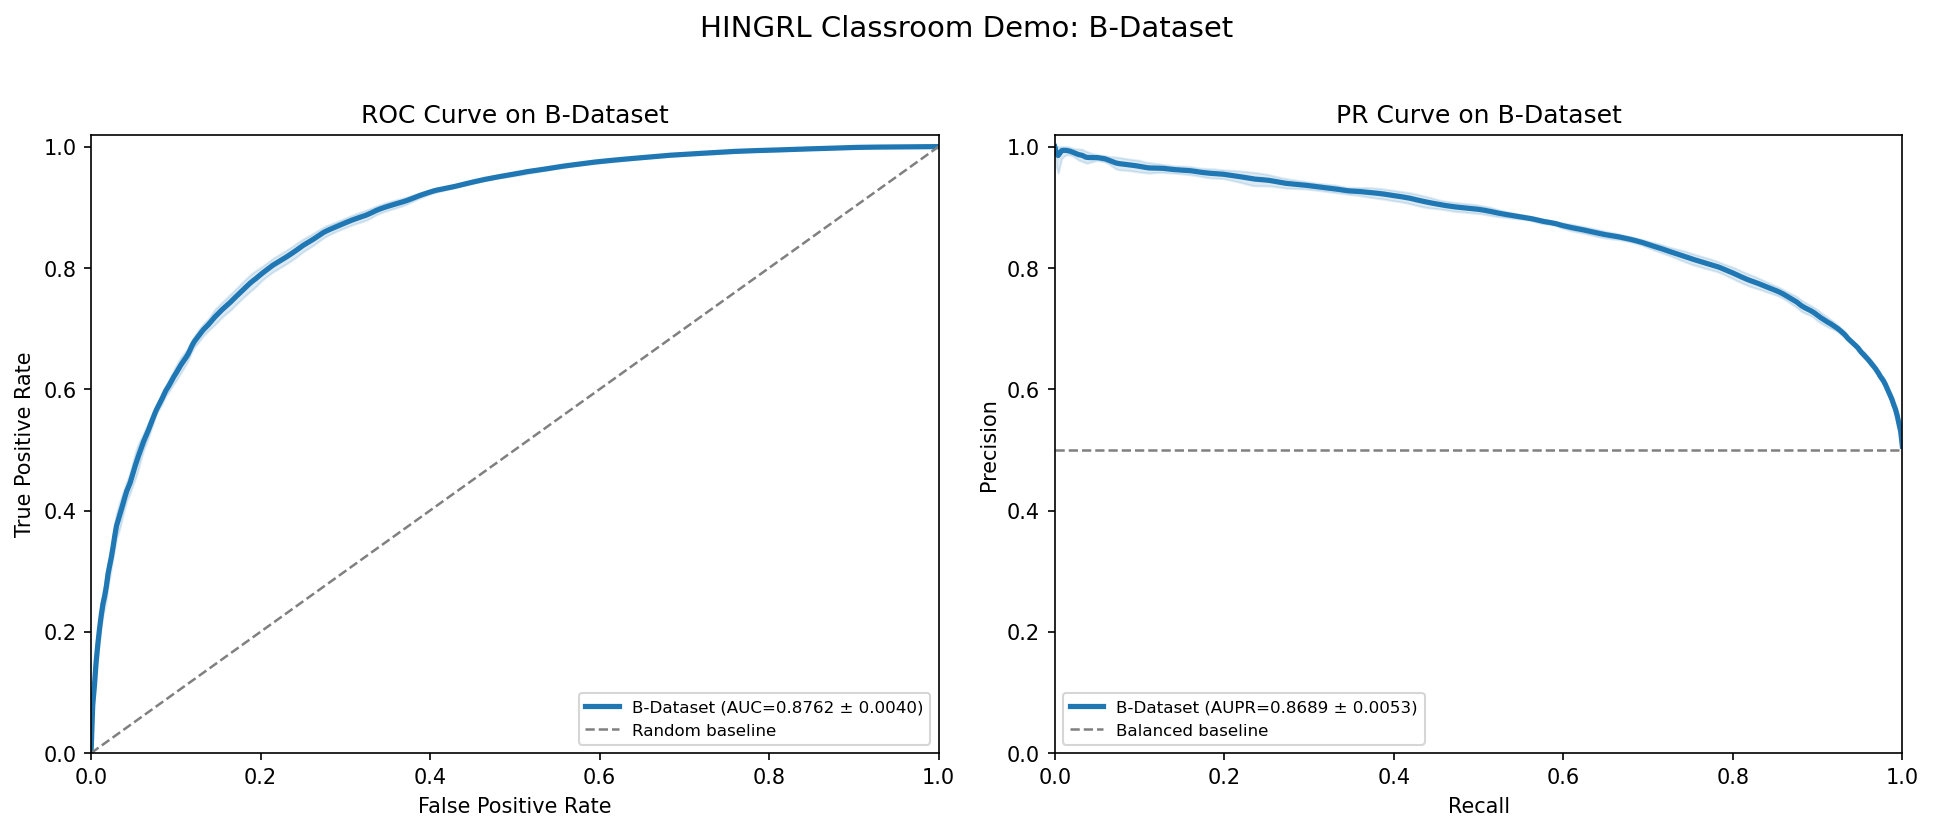

In [7]:
figure_path = OUTPUT_DIR / "hingrl_b_dataset_metrics.png"
plot_metrics(result, figure_path)


## 6. 课堂总结

这一案例完成了一个标准的图学习预测流程：

1. 从异构网络中读取药物和疾病信息
2. 构造正负样本与拼接特征
3. 用随机森林进行 5 折交叉验证
4. 用 `AUC` 和 `AUPR` 评估模型效果

从课堂结果看，`B-Dataset` 上的平均表现已经能够较稳定地区分已知关联与随机负样本。


## 7. 课后作业

请把课堂中的 `B-Dataset` 流程迁移到 `F-Dataset`，并完成下面任务：

1. 重新运行负样本生成、K 折交叉验证和模型评估
2. 比较 `F-Dataset` 与 `B-Dataset` 的 `AUC` 和 `AUPR`
3. 尝试解释两套数据在规模和表现上的差异

建议进一步思考：

- 数据规模差异会怎样影响模型稳定性？
- 为什么 `AUC` 和 `AUPR` 的变化趋势可能并不完全一致？


In [8]:
# 课后作业模板
# 将下面这行改成 "F-Dataset"，然后重新运行相关单元
homework_dataset = "F-Dataset"

# 参考步骤：
# 1. homework_result = evaluate_dataset(homework_dataset, FOLD_NUM, N_ESTIMATORS)
# 2. 查看 homework_result["fold_metrics"]
# 3. 绘制属于 F-Dataset 的 ROC / PR 图
